# Phases block extraction and comparison

First step is to use and tweak Joshua's code to get the phase block instead of solution species block.

In [1]:
import warnings
import re
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import build_database.clean_tables as ct
import build_database.utils as ut
import build_database.write_dataframes as wd
import utils
import importlib.resources as pkg_resources
import build_database.parser_dat as parser_dat

Josh had made a function for extracting different phases, so will check if this works alright.

In [2]:
database_list = pkg_resources.files('build_database.databases')
database_list = ut.phreeqc_database_list(database_list)
phases = ct.compile_phase_table(database_list)
display(phases)


Duplicate rows:
       phase_name                               dissolution_reaction  \
3        Siderite                         (FeCO3, =, Fe+2, +, CO3-2)   
4   Rhodochrosite                         (MnCO3, =, Mn+2, +, CO3-2)   
5    Strontianite                         (SrCO3, =, Sr+2, +, CO3-2)   
6       Witherite                         (BaCO3, =, Ba+2, +, CO3-2)   
8       Anhydrite                         (CaSO4, =, Ca+2, +, SO4-2)   
9       Celestite                         (SrSO4, =, Sr+2, +, SO4-2)   
10         Barite                         (BaSO4, =, Ba+2, +, SO4-2)   
34       FeS(ppt)                      (FeS, +, H+, =, Fe+2, +, HS-)   
35    Mackinawite                      (FeS, +, H+, =, Fe+2, +, HS-)   
47          H2(g)                                        (H2, =, H2)   
48          N2(g)                                        (N2, =, N2)   
49         H2S(g)                               (H2S, =, H+, +, HS-)   
61    Smithsonite                         (ZnCO3

,phase_name,dissolution_reaction,log_k,delta_h,analytic,v_m,t_c,p_c,omega,source
0,(UO2)2As2O7,(UO2)2As2O7 +2H+ +H2O = + 2H2AsO4- + 2UO2+2,7.7066,"(-145.281, kJ/mol)","(-1.6147e+002, -6.3487e-002, 1.0052e+004, 6.23...",None,None,None,None,llnl.dat
1,(UO2)2Cl3,(UO2)2Cl3 = + UO2+ + UO2+2 + 3Cl-,12.7339,"(-140.866, kJ/mol)","(-2.3895e+002, -9.2925e-002, 1.1722e+004, 9.69...",None,None,None,None,llnl.dat
2,(UO2)2P2O7,(UO2)2P2O7 +H2O = + 2HPO4-2 + 2UO2+2,-14.6827,"(-103.726, kJ/mol)","(-3.4581e+002, -1.3987e-001, 1.0703e+004, 1.36...",None,None,None,None,llnl.dat
3,(UO2)3(AsO4)2,(UO2)3(AsO4)2 +4H+ = + 2H2AsO4- + 3UO2+2,9.3177,"(-186.72, kJ/mol)","(-1.9693e+002, -7.3236e-002, 1.2936e+004, 7.46...",None,None,None,None,llnl.dat
4,(UO2)3(PO4)2,(UO2)3(PO4)2 +2H+ = + 2HPO4-2 + 3UO2+2,-14.0241,"(-149.864, kJ/mol)","(-3.6664e+002, -1.4347e-001, 1.3486e+004, 1.41...",None,None,None,None,llnl.dat
...,...,...,...,...,...,...,...,...,...,...
2791,H2(g),H2 = H2,-3.15,"(-1.759, kcal)",None,None,None,None,None,wateq4f.dat
2792,N2(g),N2 = N2,-3.26,"(-1.358, kcal)",None,None,None,None,None,wateq4f.dat
2793,H2S(g),H2S = H2S,-0.997,"(-4.570, kcal)",None,None,None,None,None,wateq4f.dat
2794,CH4(g),CH4 = CH4,-2.86,"(-3.373, kcal)",None,None,None,None,None,wateq4f.dat


Let's check which source has the most data

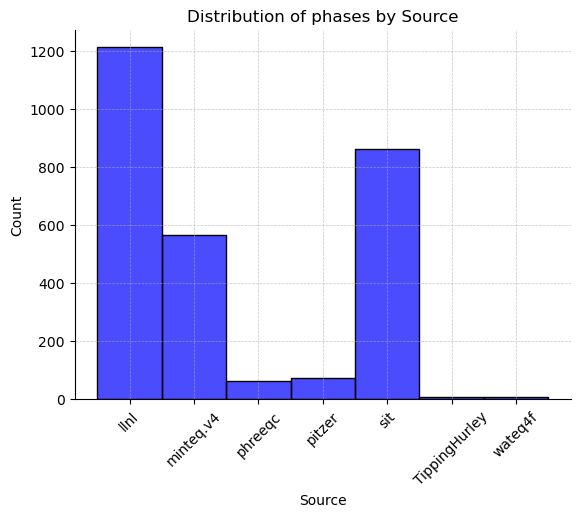

In [3]:
utils.plot_source_hist(phases,'Distribution of phases by Source')

This means that llnl has the most number of phases according to his code. Now, the code itself seems okay, so I tested it one by one if it contains all the phases in each database file.

In [4]:
# checking how many phases llnl has
phases_llnl = phases[phases['source'].str.contains('llnl')]
display(phases_llnl)
#llnl contains 1214 phases according to this.

,phase_name,dissolution_reaction,log_k,delta_h,analytic,v_m,t_c,p_c,omega,source
0,(UO2)2As2O7,(UO2)2As2O7 +2H+ +H2O = + 2H2AsO4- + 2UO2+2,7.7066,"(-145.281, kJ/mol)","(-1.6147e+002, -6.3487e-002, 1.0052e+004, 6.23...",None,None,None,None,llnl.dat
1,(UO2)2Cl3,(UO2)2Cl3 = + UO2+ + UO2+2 + 3Cl-,12.7339,"(-140.866, kJ/mol)","(-2.3895e+002, -9.2925e-002, 1.1722e+004, 9.69...",None,None,None,None,llnl.dat
2,(UO2)2P2O7,(UO2)2P2O7 +H2O = + 2HPO4-2 + 2UO2+2,-14.6827,"(-103.726, kJ/mol)","(-3.4581e+002, -1.3987e-001, 1.0703e+004, 1.36...",None,None,None,None,llnl.dat
3,(UO2)3(AsO4)2,(UO2)3(AsO4)2 +4H+ = + 2H2AsO4- + 3UO2+2,9.3177,"(-186.72, kJ/mol)","(-1.9693e+002, -7.3236e-002, 1.2936e+004, 7.46...",None,None,None,None,llnl.dat
4,(UO2)3(PO4)2,(UO2)3(PO4)2 +2H+ = + 2HPO4-2 + 3UO2+2,-14.0241,"(-149.864, kJ/mol)","(-3.6664e+002, -1.4347e-001, 1.3486e+004, 1.41...",None,None,None,None,llnl.dat
...,...,...,...,...,...,...,...,...,...,...
1209,UOF4(g),UOF4 +H2O = + UO2+2 + 2H+ + 4F-,24.2848,"(-312.552, kJ/mol)","(-3.9592e+002, -1.3699e-001, 2.4127e+004, 1.53...",None,None,None,None,llnl.dat
1210,Xe(g),Xe = + Xe,-2.364,"(-18.8698, kJ/mol)","(-2.0636e+001, 5.1389e-003, 2.0490e+002, 5.191...",None,None,None,None,llnl.dat
1211,Zn(g),Zn +2H+ +0.5000 O2 = + H2O + Zn+2,85.414,"(-563.557, kJ/mol)","(-1.0898e+001, -3.9871e-003, 2.9068e+004, 0.00...",None,None,None,None,llnl.dat
1212,Zr(g),Zr +4H+ +O2 = + Zr+4 + 2H2O,277.1324,"(0,)",None,None,None,None,None,llnl.dat


In [5]:
#So I copied and pasted whole 'phases' section from llnl and made a simple code to count the lines that don't start with # or a tab.
phasefile = open("llnl_phase.txt","r")
outputphase = open("llnl_phasename.txt","w")
all_lines = phasefile.readlines()
for i in range(0,len(all_lines)):
    line = all_lines[i]
    
    if line != "" and line[0] != '#' and line[0] != '\t' and line[0] != '\n' and line[0] != ' ':
        outputphase.write(all_lines[i])

phasefile.close()
outputphase.close()
# the result showed that there are 1215 phases in phases block

Okay, so I will check if phases 'missed' one, or sensed the wrong 'duplicates'. If it missed one, there should be something printed underneath the python shell. If not, Josh's code accidentally deemed something 'duplicates' that weren't duplicate.

In [6]:
outputphase = open("llnl_phasename.txt",'r')
all_lines = outputphase.readlines()
for i in range(0,len(all_lines)):
    line = all_lines[i].strip()
    line_clean = line.strip()
    name_clean = phases_llnl['phase_name'].str.strip()
    name_clean.to_csv("phase_names.txt", index=False, header=False)


    if not (name_clean == line_clean).any():
        print(line)

outputphase.close()

Na


So it seems Josh missed the Na block:

Na

       Na +1.0000 H+ +0.2500 O2  =  + 0.5000 H2O + 1.0000 Na+
        log_k           67.3804
	-delta_H	-380.185	kJ/mol	# Calculated enthalpy of reaction	Na
	Enthalpy of formation:	0 kJ/mol
        -analytic -4.0458e+001 -8.7899e-003 2.1223e+004 1.5927e+001 -1.2715e+004
       -Range:  0-300

Unfortunately my Urop's running out of time so let's check other databases as well and see if this can be ignored...

In [7]:
# checking how many phases other databases have
phases_sit = phases[phases['source'].str.contains('sit')]
print(len(phases_sit))
#sit contains 862 phases according to this.
phases_minteq = phases[phases['source'].str.contains('minteq')]
print(len(phases_minteq))
#minteq.v4 contains 568 phases according to this.
phases_phreeqc = phases[phases['source'].str.contains('phreeqc')]
print(len(phases_phreeqc))
#phreeqc contains 71 phases according to this.
phases_pitzer = phases[phases['source'].str.contains('pitzer')]
print(len(phases_pitzer))
#pitzer contains 72 phases according to this.

862
568
64
72


1. SIT

In [8]:
phasefile = open("sit_phase.txt","r")
outputphase = open("sit_phasename.txt","w")
all_lines = phasefile.readlines()
for i in range(0,len(all_lines)):
    line = all_lines[i]
    
    if line != "" and line[0] != '#' and line[0] != '\t' and line[0] != '\n' and line[0] != ' ':
        outputphase.write(all_lines[i])

phasefile.close()
outputphase.close()

# number of phases is 863

In [9]:
outputphase = open("sit_phasename.txt",'r')
all_lines = outputphase.readlines()
for i in range(0,len(all_lines),2):
    line = all_lines[i].strip()
    line_clean = line.strip()
    name_clean = phases_sit['phase_name'].str.strip()
    name_clean.to_csv("phase_names_sit.txt", index=False, header=False)

    if not (name_clean == line_clean).any():
        print(line)

outputphase.close()

NpO2(CO3)(s)


2. minteq.v4

In [10]:
phasefile = open("minteq_phase.txt","r")
outputphase = open("minteq_phasename.txt","w")
all_lines = phasefile.readlines()
for i in range(0,len(all_lines)):
    line = all_lines[i]
    
    if line != "" and line[0] != '#' and line[0] != '\t' and line[0] != '\n' and line[0] != ' ':
        outputphase.write(all_lines[i])

phasefile.close()
outputphase.close()

# number of phases is 568(correct)
# Now a new problem since the changed code says that minteq.v4 has 645 phases...

3. phreeqc

In [11]:
phasefile = open("phreeqc_phase.txt","r")
outputphase = open("phreeqc_phasename.txt","w")
all_lines = phasefile.readlines()
for i in range(0,len(all_lines)):
    line = all_lines[i]
    
    if line != "" and line[0] != '#' and line[0] != '\t' and line[0] != '\n' and line[0] != ' ':
        outputphase.write(all_lines[i])

phasefile.close()
outputphase.close()
# number of phases is 71(correct)

In [12]:
outputphase = open("phreeqc_phasename.txt",'r')
all_lines = outputphase.readlines()
for i in range(0,len(all_lines)):
    line = all_lines[i].strip()
    line_clean = line.strip()
    name_clean = phases_phreeqc['phase_name'].str.strip()
    name_clean.to_csv("phase_names_phreeqc.txt", index=False, header=False)

    if not (name_clean == line_clean).any():
        print(line)

outputphase.close()

Pyrolusite # H2O added for surface calc's
Willemite 289
Otavite 315
CdSiO3 328
CdSO4 329
Cerussite 365
Anglesite 384
Pb(OH)2 389


4. pitzer

In [13]:
phasefile = open("pitzer_phase.txt","r")
outputphase = open("pitzer_phasename.txt","w")
all_lines = phasefile.readlines()
for i in range(0,len(all_lines)):
    line = all_lines[i]
    
    if line != "" and line[0] != '#' and line[0] != '\t' and line[0] != '\n' and line[0] != ' ':
        outputphase.write(all_lines[i])

phasefile.close()
outputphase.close()
# number of phases is 72(correct)

Since I don't think fixing this code will be done in the rest of the week, after Martin confirms that this missed species are fine, I'll proceed with my UROP first and correct the codes later. And I will copy&paste phases from sit, minteq, phreeqc, minteq.v4 to the phases block of llnl base, since that is the easiest thing to do.

In [14]:
# let's start by making a dataframe that contains phases that don't exist originally in llnl
rest_unique = phases[~phases['phase_name'].isin(phases_llnl['phase_name'])]
display(rest_unique)

# let's remove duplicates from different sources.
before = len(rest_unique)
filter_columns = ['phase_name']
phases_new = rest_unique.drop_duplicates(subset=filter_columns)
after = len(phases_new)
display(phases_new)
print(f'Filtered {before - after} duplicate rows from the rest of the phases table')

,phase_name,dissolution_reaction,log_k,delta_h,analytic,v_m,t_c,p_c,omega,source
1214,Sulfur,S + H+ + 2e- = HS-,-2.1449,"(-16.3, kJ)",None,None,None,None,None,minteq.v4.dat
1215,Semetal(hex),Se + H+ + 2e- = HSe-,-7.7084,"(15.9, kJ)",None,None,None,None,None,minteq.v4.dat
1216,Semetal(am),Se + H+ + 2e- = HSe-,-7.1099,"(10.8784, kJ)",None,None,None,None,None,minteq.v4.dat
1217,Sbmetal,Sb + 3H2O = Sb(OH)3 + 3H+ + 3e-,-11.6889,"(83.89, kJ)",None,None,None,None,None,minteq.v4.dat
1218,Snmetal(wht),Sn + 2H2O = Sn(OH)2 + 2H+ + 2e-,-2.3266,"(-0, kJ)",None,None,None,None,None,minteq.v4.dat
...,...,...,...,...,...,...,...,...,...,...
2764,ZrF3(s),ZrF3 = 3F- + 1Zr+4 + 0.500H2O - 1H+ - 0.250O2,24.295,"(-321.432,)","(-3.20173E+1, 0E+0, 1.67895E+4, 0E+0, 0E+0)",None,None,None,None,sit.dat
2766,ZrI4(cr),ZrI4 = 4I- + 1Zr+4,44.59,"(-346.720,)","(-1.61526E+1, 0E+0, 1.81104E+4, 0E+0, 0E+0)",None,None,None,None,sit.dat
2767,ZrO2(cr),ZrO2 = - 4H+ + 1Zr+4 + 2H2O,-7.0,"(-79.560,)","(-2.09383E+1, 0E+0, 4.1557E+3, 0E+0, 0E+0)",None,None,None,None,sit.dat
2768,ZrSiO4(s),ZrSiO4 = - 4H+ + 1H4(SiO4) + 1Zr+4,-14.36,"(-35.494,)","(-2.05783E+1, 0E+0, 1.85398E+3, 0E+0, 0E+0)",None,None,None,None,sit.dat


,phase_name,dissolution_reaction,log_k,delta_h,analytic,v_m,t_c,p_c,omega,source
1214,Sulfur,S + H+ + 2e- = HS-,-2.1449,"(-16.3, kJ)",None,None,None,None,None,minteq.v4.dat
1215,Semetal(hex),Se + H+ + 2e- = HSe-,-7.7084,"(15.9, kJ)",None,None,None,None,None,minteq.v4.dat
1216,Semetal(am),Se + H+ + 2e- = HSe-,-7.1099,"(10.8784, kJ)",None,None,None,None,None,minteq.v4.dat
1217,Sbmetal,Sb + 3H2O = Sb(OH)3 + 3H+ + 3e-,-11.6889,"(83.89, kJ)",None,None,None,None,None,minteq.v4.dat
1218,Snmetal(wht),Sn + 2H2O = Sn(OH)2 + 2H+ + 2e-,-2.3266,"(-0, kJ)",None,None,None,None,None,minteq.v4.dat
...,...,...,...,...,...,...,...,...,...,...
2764,ZrF3(s),ZrF3 = 3F- + 1Zr+4 + 0.500H2O - 1H+ - 0.250O2,24.295,"(-321.432,)","(-3.20173E+1, 0E+0, 1.67895E+4, 0E+0, 0E+0)",None,None,None,None,sit.dat
2766,ZrI4(cr),ZrI4 = 4I- + 1Zr+4,44.59,"(-346.720,)","(-1.61526E+1, 0E+0, 1.81104E+4, 0E+0, 0E+0)",None,None,None,None,sit.dat
2767,ZrO2(cr),ZrO2 = - 4H+ + 1Zr+4 + 2H2O,-7.0,"(-79.560,)","(-2.09383E+1, 0E+0, 4.1557E+3, 0E+0, 0E+0)",None,None,None,None,sit.dat
2768,ZrSiO4(s),ZrSiO4 = - 4H+ + 1H4(SiO4) + 1Zr+4,-14.36,"(-35.494,)","(-2.05783E+1, 0E+0, 1.85398E+3, 0E+0, 0E+0)",None,None,None,None,sit.dat


Filtered 23 duplicate rows from the rest of the phases table


In [15]:
#Write this information into a txt file
with open("phases_to_copy.txt", "w") as f:
    phases_new.apply(lambda row: wd.write_phase(row, f), axis=1)

# Fixing the code
Josh's code doesn't catch phases with the space in it, so let's fix it first by using re.compile(r"^(?!.*=).+$")

class PhaseParser(BaseParser):
    """Class for parsing phase species in phreeqc database files"""

    def __init__(self, database_file_path) -> None:
        """
        Initialize the PhaseParser class.

        Parameters:
        - database_file_path (str): The path to the database file.
        """
        super().__init__(database_file_path, "PHASES", "EXCHANGE")
        # momentarily changed it to a new bit to test if it catches the missing part
        #self.block_start = re.compile(r"^(?!\s)\S+$")
        self.block_start = re.compile(r"^(?!.*=).+$")
        self.patterns = {
            "dissolution_reaction": re.compile(r"^.*\s=\s.*"),
            "log_k": re.compile(r"^\s*[-]*log[ _]*k"),
            "delta_h": re.compile(r"\s*[-]*delta.*"),
            "analytic": re.compile(r"^\s*[-]*analytic"),
            "v_m": re.compile(r"^\s*[-]*Vm"),
            "t_c": re.compile(r"^\s*[-]*T_c"),
            "p_c": re.compile(r"^\s*[-]*P_c"),
            "omega": re.compile(r"^\s*[-]*Omega"),
        }

In [16]:
import re

lines = [
    "Pyrolusite # H2O added for surface calc's",
    "Willemite 289",
    "Otavite 315",
    "CdSiO3 328",
    "CdSO4 329",
    "Cerussite 365",
    "Anglesite 384",
    "Pb(OH)2 389"
]

pattern = re.compile(r"^(?!.*=).+$")

for line in lines:
    print(f"'{line}':", bool(pattern.match(line)))

'Pyrolusite # H2O added for surface calc's': True
'Willemite 289': True
'Otavite 315': True
'CdSiO3 328': True
'CdSO4 329': True
'Cerussite 365': True
'Anglesite 384': True
'Pb(OH)2 389': True
